# Predicting Student Health Risk — Exploratory Data Analysis

This notebook provides a reproducible first-pass EDA for the Playground Series S6E7 data. It checks schema, data quality, missingness, class imbalance, feature distributions, train/test drift, and relationships with the target.

**Primary metric:** balanced accuracy. This matters because the target is highly imbalanced.

In [3]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid', context='notebook')
RANDOM_STATE = 42
DATA_DIR = Path('.')

## 1. Load and identify columns

In [4]:
train = pd.read_csv(DATA_DIR / 'train.csv')
test = pd.read_csv(DATA_DIR / 'test.csv')
sample_submission = pd.read_csv(DATA_DIR / 'sample_submission.csv')

TARGET = 'health_condition'
ID_COL = 'id'
FEATURES = [c for c in test.columns if c != ID_COL]
NUM_COLS = test[FEATURES].select_dtypes(include=np.number).columns.tolist()
CAT_COLS = [c for c in FEATURES if c not in NUM_COLS]

#print(f'train: {train.shape:,} | test: {test.shape:,}')
print(f'numerical: {len(NUM_COLS)} | categorical: {len(CAT_COLS)}')
display(train.head())

numerical: 7 | categorical: 6


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [5]:
schema = pd.DataFrame({
    'dtype': train.dtypes.astype(str),
    'non_null': train.notna().sum(),
    'missing_n': train.isna().sum(),
    'missing_pct': train.isna().mean().mul(100).round(2),
    'unique': train.nunique(dropna=False),
})
display(schema)
print('Duplicate IDs:', train[ID_COL].duplicated().sum())
print('Duplicate feature rows:', train[FEATURES].duplicated().sum())

,dtype,non_null,missing_n,missing_pct,unique
id,int64,690088,0,0.00,690088
health_condition,object,690088,0,0.00,3
sleep_duration,float64,614089,75999,11.01,702
heart_rate,float64,682255,7833,1.14,538
bmi,float64,676190,13898,2.01,1597
calorie_expenditure,float64,637235,52853,7.66,2102
step_count,float64,676172,13916,2.02,12808
exercise_duration,float64,683187,6901,1.00,857
water_intake,float64,646611,43477,6.30,401
diet_type,object,683187,6901,1.00,4


Duplicate IDs: 0
Duplicate feature rows: 0


## 2. Target balance

,count,pct
health_condition,,
at-risk,592561,85.87
unhealthy,57724,8.36
fit,39803,5.77


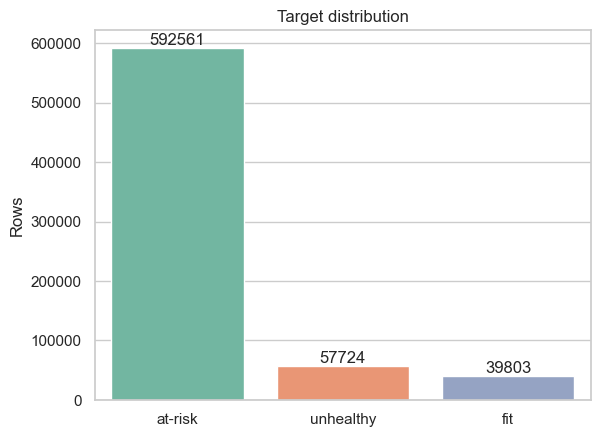

In [6]:
target_summary = train[TARGET].value_counts().to_frame('count')
target_summary['pct'] = train[TARGET].value_counts(normalize=True).mul(100).round(2)
display(target_summary)

ax = sns.countplot(data=train, x=TARGET, order=target_summary.index, palette='Set2')
ax.set(title='Target distribution', xlabel='', ylabel='Rows')
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')
plt.show()

## 3. Missing values

,train_pct,test_pct,gap_pp
stress_level,12.000,12.000,-0.0
sleep_duration,11.013,11.013,-0.0
sleep_quality,8.453,8.453,-0.0
calorie_expenditure,7.659,7.659,0.0
water_intake,6.300,6.300,-0.0
physical_activity_level,5.307,5.307,0.0
smoking_alcohol,4.142,4.142,-0.0
gender,3.097,3.097,0.0
step_count,2.017,2.017,-0.0
bmi,2.014,2.014,-0.0


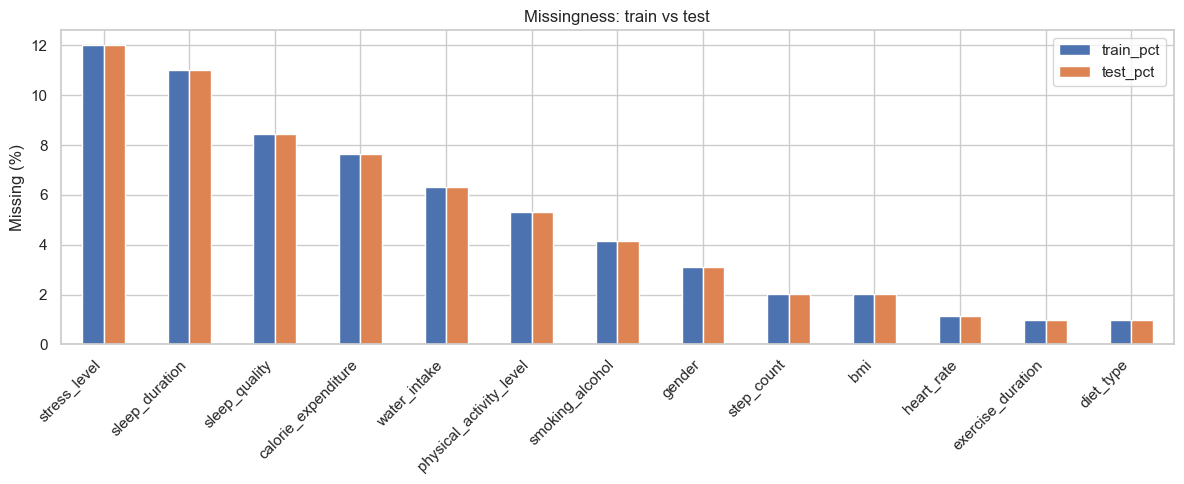

In [7]:
missing = pd.DataFrame({
    'train_pct': train[FEATURES].isna().mean().mul(100),
    'test_pct': test[FEATURES].isna().mean().mul(100),
}).sort_values('train_pct', ascending=False)
missing['gap_pp'] = missing['test_pct'] - missing['train_pct']
display(missing.round(3))

missing[['train_pct', 'test_pct']].plot.bar(figsize=(12, 5))
plt.ylabel('Missing (%)'); plt.title('Missingness: train vs test'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

,train,test
count,690088.000000,295753.000000
mean,0.651360,0.651361
std,0.772452,0.889748
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,1.000000,1.000000
max,6.000000,8.000000


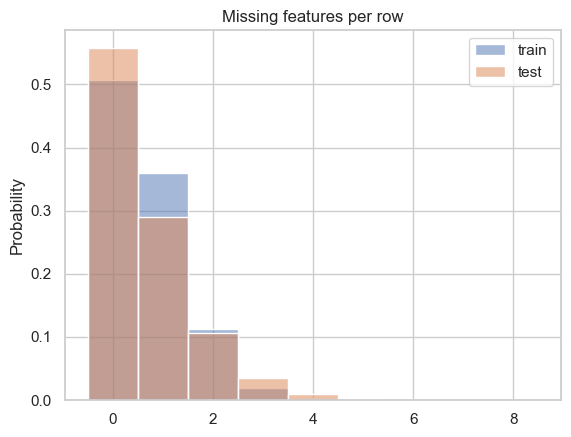

In [8]:
train_missing_count = train[FEATURES].isna().sum(axis=1)
test_missing_count = test[FEATURES].isna().sum(axis=1)
display(pd.DataFrame({'train': train_missing_count.describe(), 'test': test_missing_count.describe()}))

sns.histplot(train_missing_count, discrete=True, stat='probability', label='train', alpha=.5)
sns.histplot(test_missing_count, discrete=True, stat='probability', label='test', alpha=.5)
plt.title('Missing features per row'); plt.legend(); plt.show()

## 4. Numerical distributions and train/test drift

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
sleep_duration,614089.0,6.992597,1.215407,3.0,4.19,4.95,6.16,6.99,7.81,9.05,9.92,10.00
heart_rate,682255.0,75.096504,8.175106,50.0,56.30,61.80,69.40,75.10,80.70,88.60,93.70,107.70
bmi,676190.0,22.984925,2.481787,16.0,17.15,18.87,21.32,22.99,24.66,27.08,28.84,34.82
calorie_expenditure,637235.0,2226.084931,347.532098,1200.0,1404.00,1626.00,2053.00,2241.00,2456.00,2781.00,2979.00,3580.00
step_count,676172.0,8615.953050,3929.399831,1002.0,1211.00,1769.00,5389.00,8856.00,12114.00,14253.00,14762.00,14999.00
exercise_duration,683187.0,38.751456,14.742189,0.0,0.00,14.40,29.20,39.40,49.40,61.40,67.40,99.80
water_intake,646611.0,2.188542,0.518489,0.5,0.86,1.42,1.84,2.17,2.50,3.12,3.44,4.72


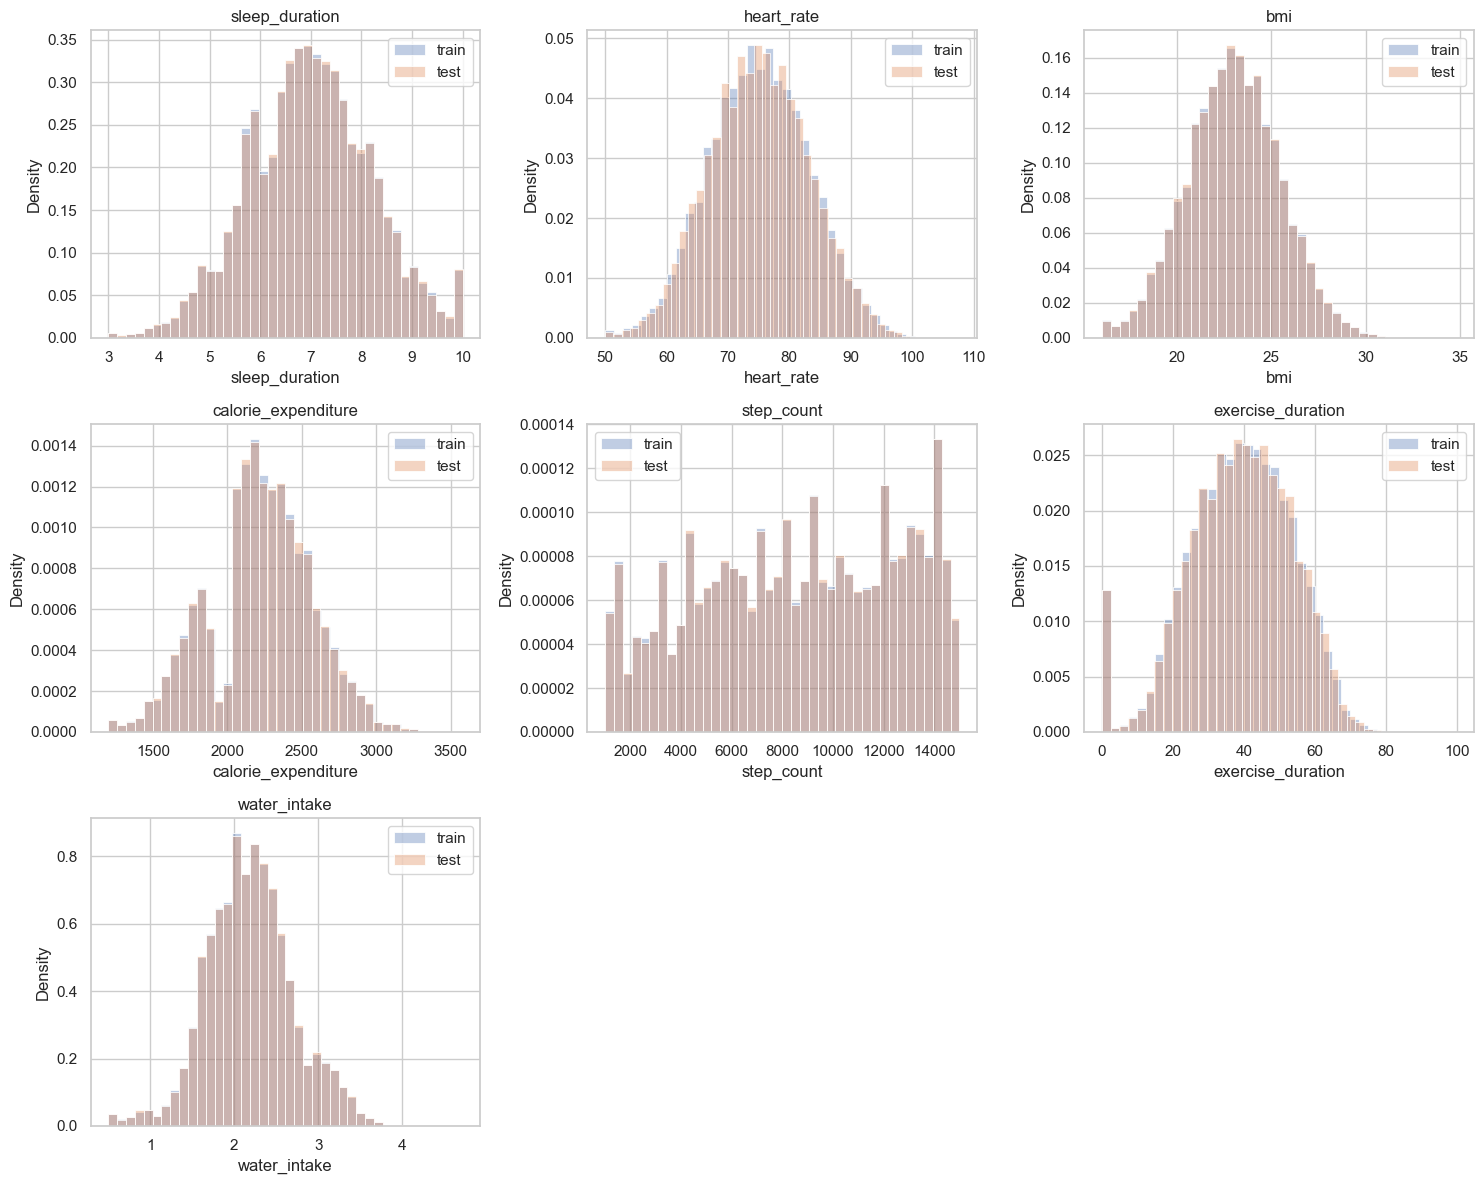

In [9]:
display(train[NUM_COLS].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T)

ncols = 3
nrows = int(np.ceil(len(NUM_COLS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4*nrows))
axes = np.atleast_1d(axes).ravel()
for ax, col in zip(axes, NUM_COLS):
    sns.histplot(train[col], bins=40, stat='density', alpha=.35, label='train', ax=ax)
    sns.histplot(test[col], bins=40, stat='density', alpha=.35, label='test', ax=ax)
    ax.set_title(col); ax.legend()
for ax in axes[len(NUM_COLS):]: ax.remove()
plt.tight_layout(); plt.show()

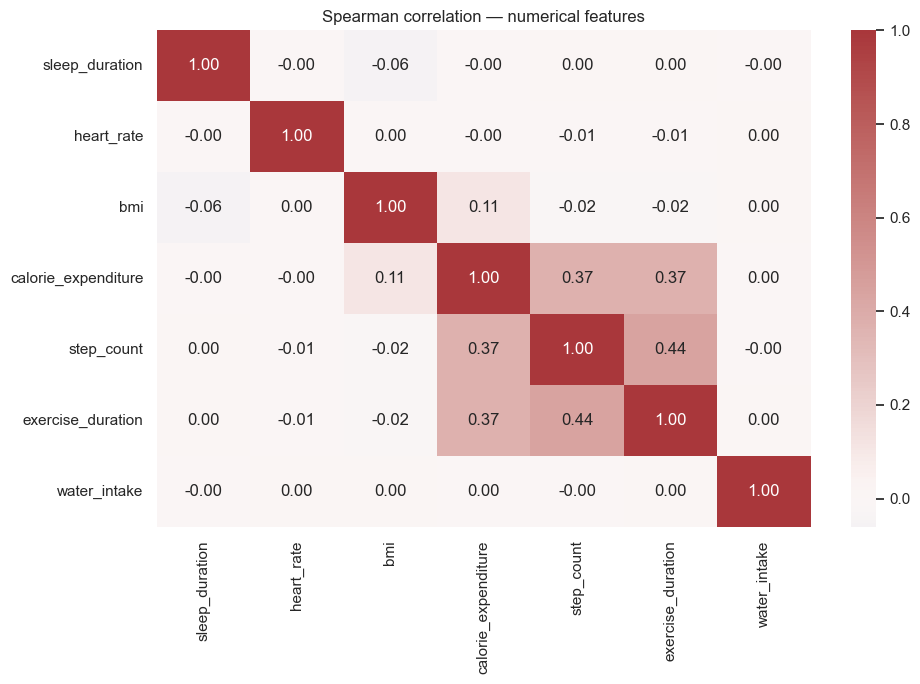

In [10]:
corr = train[NUM_COLS].corr(method='spearman')
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0)
plt.title('Spearman correlation — numerical features')
plt.tight_layout(); plt.show()

## 5. Categorical distributions and target rates

In [11]:
for col in CAT_COLS:
    comparison = pd.concat([
        train[col].fillna('<MISSING>').value_counts(normalize=True).rename('train'),
        test[col].fillna('<MISSING>').value_counts(normalize=True).rename('test'),
    ], axis=1).fillna(0)
    comparison['abs_gap'] = (comparison['train'] - comparison['test']).abs()
    print(f'\n{col}')
    display(comparison.sort_values('train', ascending=False).style.format('{:.3%}'))


diet_type


,train,test,abs_gap
diet_type,,,
veg,33.537%,33.498%,0.039%
balanced,32.878%,32.961%,0.082%
non-veg,32.585%,32.542%,0.044%
,1.000%,1.000%,0.000%



stress_level


,train,test,abs_gap
stress_level,,,
medium,37.940%,38.061%,0.122%
high,25.758%,25.639%,0.119%
low,24.302%,24.300%,0.003%
,12.000%,12.000%,0.000%



sleep_quality


...

,train,test,abs_gap
physical_activity_level,,,
moderate,32.031%,32.286%,0.256%
sedentary,31.849%,32.449%,0.601%
active,30.814%,29.957%,0.856%
,5.307%,5.307%,0.000%



smoking_alcohol


,train,test,abs_gap
smoking_alcohol,,,
yes,32.421%,32.216%,0.204%
no,31.850%,31.979%,0.129%
occasional,31.588%,31.663%,0.075%
,4.142%,4.142%,0.000%



gender


,train,test,abs_gap
gender,,,
male,34.453%,34.635%,0.182%
female,32.462%,29.153%,3.309%
other,29.988%,33.115%,3.127%
,3.097%,3.097%,0.000%


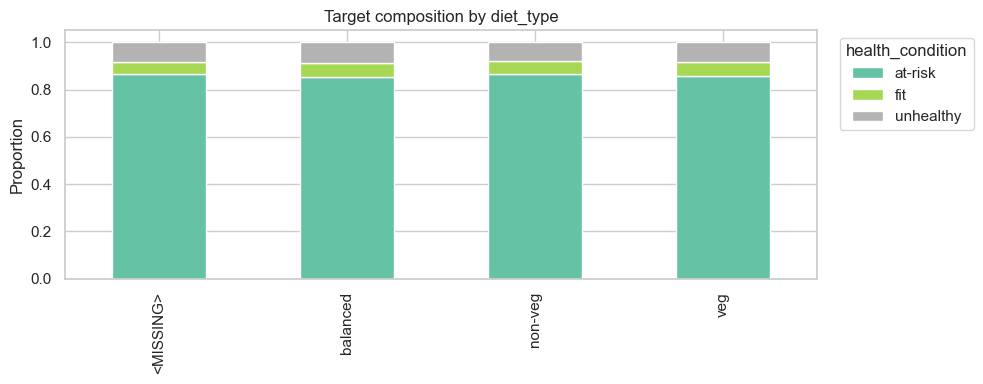

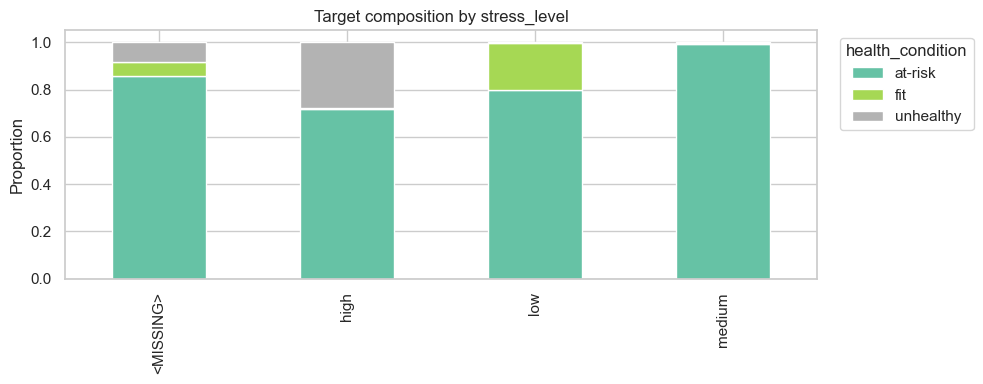

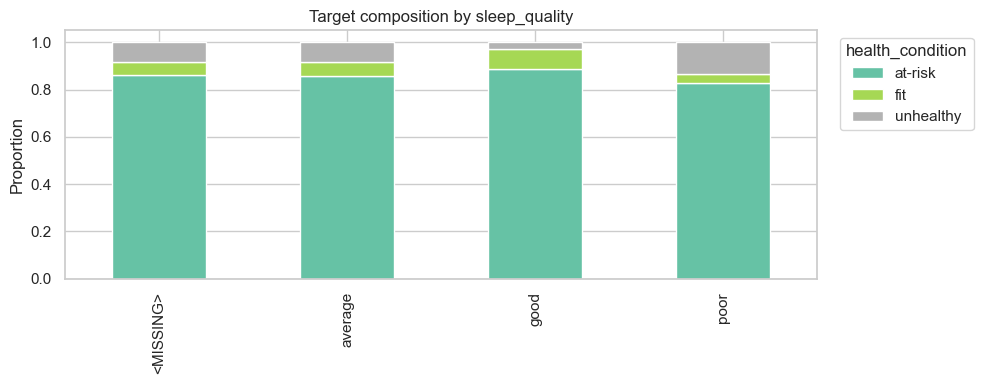

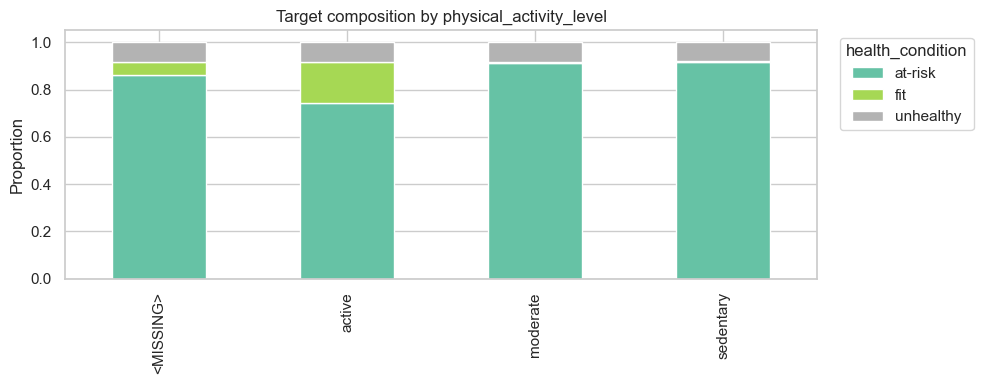

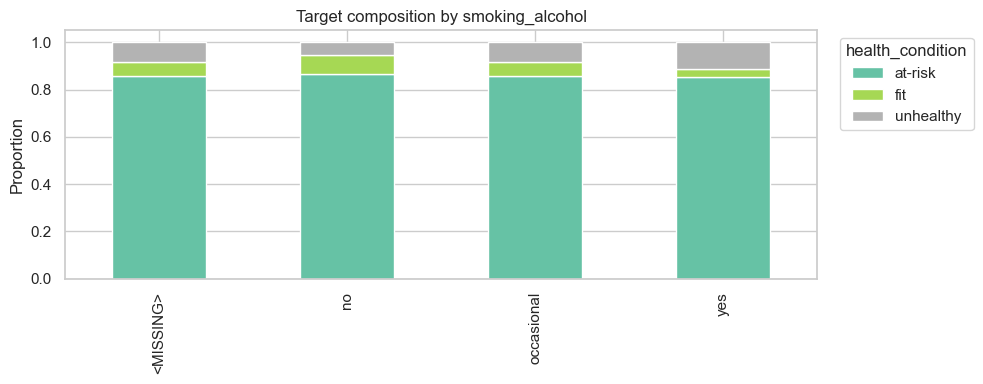

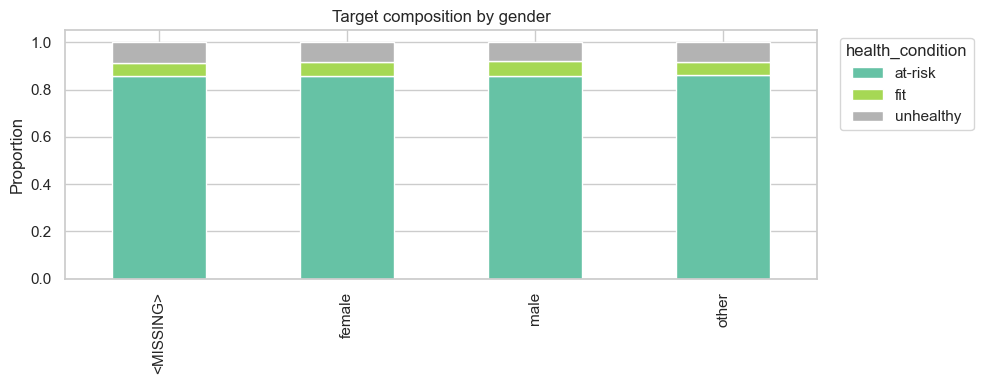

In [12]:
for col in CAT_COLS:
    table = pd.crosstab(train[col].fillna('<MISSING>'), train[TARGET], normalize='index')
    table.plot.bar(stacked=True, figsize=(10, 4), colormap='Set2')
    plt.title(f'Target composition by {col}')
    plt.ylabel('Proportion'); plt.xlabel(''); plt.legend(title=TARGET, bbox_to_anchor=(1.02, 1))
    plt.tight_layout(); plt.show()

## 6. Numerical features by target

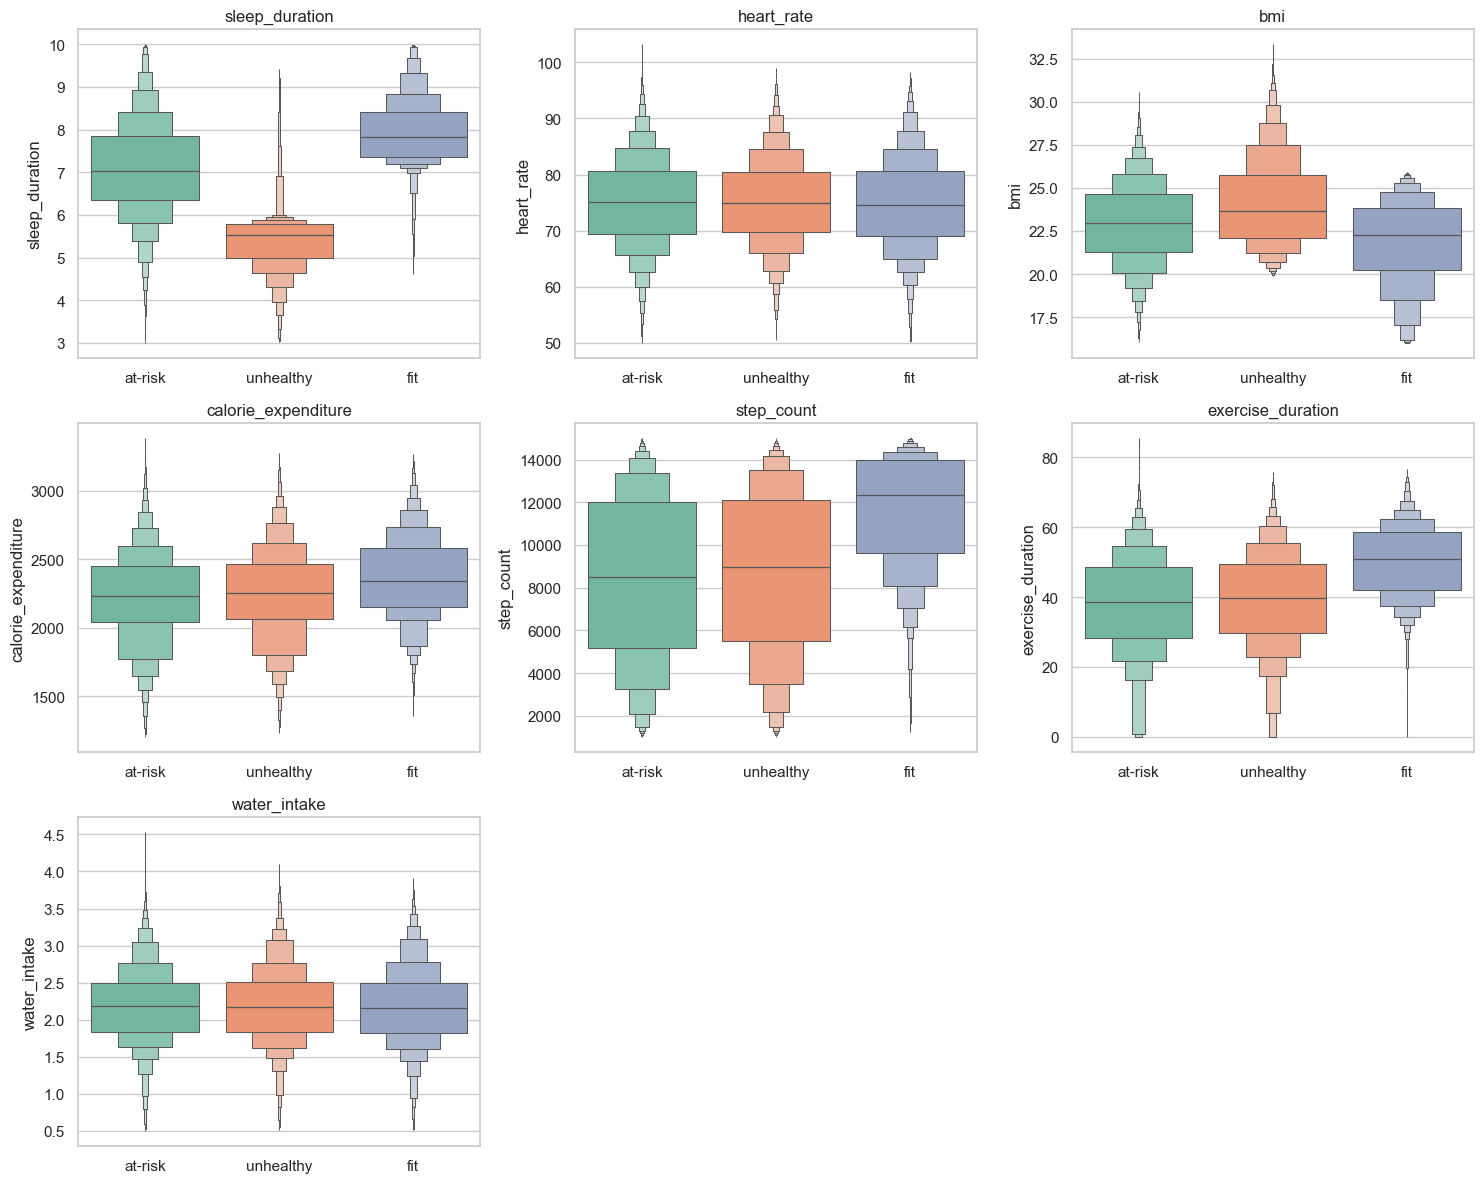

In [13]:
plot_sample = train.sample(min(100_000, len(train)), random_state=RANDOM_STATE)
ncols = 3
nrows = int(np.ceil(len(NUM_COLS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4*nrows))
axes = np.atleast_1d(axes).ravel()
for ax, col in zip(axes, NUM_COLS):
    sns.boxenplot(data=plot_sample, x=TARGET, y=col, ax=ax, palette='Set2', showfliers=False)
    ax.set_title(col); ax.set_xlabel('')
for ax in axes[len(NUM_COLS):]: ax.remove()
plt.tight_layout(); plt.show()

## 7. Compact drift report

In [14]:
from scipy.stats import ks_2samp

drift_rows = []
for col in NUM_COLS:
    a, b = train[col].dropna(), test[col].dropna()
    stat, p = ks_2samp(a, b)
    drift_rows.append((col, 'numeric', stat, p))
for col in CAT_COLS:
    a = train[col].fillna('<MISSING>').value_counts(normalize=True)
    b = test[col].fillna('<MISSING>').value_counts(normalize=True)
    idx = a.index.union(b.index)
    tvd = 0.5 * (a.reindex(idx, fill_value=0) - b.reindex(idx, fill_value=0)).abs().sum()
    drift_rows.append((col, 'categorical', tvd, np.nan))

drift = pd.DataFrame(drift_rows, columns=['feature', 'type', 'drift_stat', 'p_value'])
display(drift.sort_values('drift_stat', ascending=False))

,feature,type,drift_stat,p_value
12,gender,categorical,0.033092,NaN
10,physical_activity_level,categorical,0.008563,NaN
6,water_intake,numeric,0.003355,0.025299
4,step_count,numeric,0.002347,0.213390
11,smoking_alcohol,categorical,0.002043,NaN
1,heart_rate,numeric,0.001999,0.386290
0,sleep_duration,numeric,0.001791,0.594842
3,calorie_expenditure,numeric,0.001680,0.652375
5,exercise_duration,numeric,0.001648,0.633504
9,sleep_quality,categorical,0.001330,NaN


## Findings checklist

After running the notebook, record:

- The degree of target imbalance and why balanced accuracy is appropriate.
- Features with substantial missingness or different missingness in test.
- Implausible ranges/outliers that may require clipping or domain checks.
- Categorical levels with visibly different class composition.
- Features showing the largest train/test drift.
- Candidate feature interactions for the modeling notebook.